In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set a clean visual theme
sns.set_theme(style="whitegrid")
print("Libraries loaded for Fraud Detection.")

Libraries loaded for Fraud Detection.


In [ ]:
#path to specific files
train_path = "Dataset/fraudTrain.csv"
test_path = "Dataset/fraudTest.csv"

# 2. Load the data into separate DataFrames
cc_train = pd.read_csv(train_path)
cc_test = pd.read_csv(test_path)

print(f"Training rows: {cc_train.shape[0]}")
print(f"Testing rows: {cc_test.shape[0]}")

# showing few columns of the training data
display(cc_train.head())

Training rows: 1296675
Testing rows: 555719


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# target column here is is_fraud
tgt_col = 'is_fraud'

# Dropping useless index columns if they exist (Ex: 'Unnamed: 0')
if 'Unnamed: 0' in cc_train.columns:
    cc_train = cc_train.drop(columns=['Unnamed: 0'])
    cc_test = cc_test.drop(columns=['Unnamed: 0'])

#Automatically select only numeric columns for features
num_cols = cc_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Ensuring target column isn't accidentally in the feature list
if tgt_col in num_cols:
    num_cols.remove(tgt_col)

# 3. Creating final Training and Testing batches
x_trn = cc_train[num_cols].fillna(0) # Fill any missing numbers with 0
y_trn = cc_train[tgt_col]

x_tst = cc_test[num_cols].fillna(0)
y_tst = cc_test[tgt_col]

print("Data cleaned. Using the numerical features to find fraud:")
print(num_cols)

Data cleaned. Using the numerical features to find fraud:
['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']


In [4]:
# Initialize Random Forest
# for imbalanced fraud data, using class_weight='balanced' for optimization in training
fraud_engine = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1 # Uses all your computer's CPU cores to train faster
)

# Train the model
print("Training the fraud engine... (This might take time depending on data size.)")
fraud_engine.fit(x_trn, y_trn)

print("Training complete!!")

Training the fraud engine... (This might take time depending on data size.)
Training complete!!


In [5]:
# Making predictions on the test set
fraud_preds = fraud_engine.predict(x_tst)

print(f"Overall Accuracy: {accuracy_score(y_tst, fraud_preds) * 100:.2f}%\n")

print("--- Detailed Fraud Report ---")
# '0' is Normal, '1' is Fraud
print(classification_report(y_tst, fraud_preds, target_names=['Normal Transaction', 'Fraudulent Transaction']))

Overall Accuracy: 96.03%

--- Detailed Fraud Report ---
                        precision    recall  f1-score   support

    Normal Transaction       1.00      0.96      0.98    553574
Fraudulent Transaction       0.07      0.74      0.13      2145

              accuracy                           0.96    555719
             macro avg       0.53      0.85      0.55    555719
          weighted avg       1.00      0.96      0.98    555719



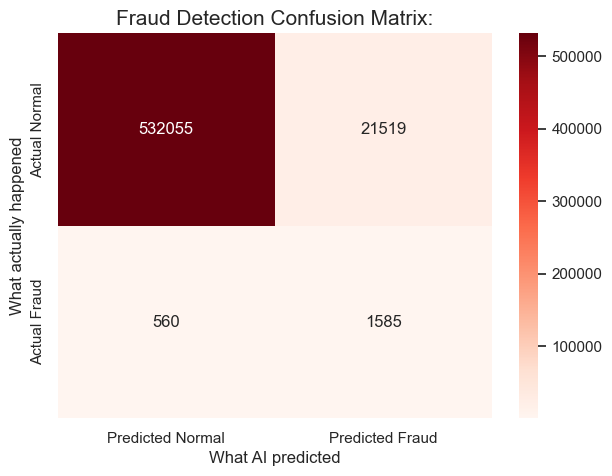

In [6]:
plt.figure(figsize=(7, 5))

# Generate confusion matrix using the result
cm = confusion_matrix(y_tst, fraud_preds)

# Plotting in robust design
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])

plt.title('Fraud Detection Confusion Matrix:', fontsize=15)
plt.ylabel('What actually happened', fontsize=12)
plt.xlabel('What AI predicted', fontsize=12)
plt.show()

C:\Users\sw\AppData\Local\Temp\ipykernel_6772\2752363231.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal (0)', 'Fraud (1)'])


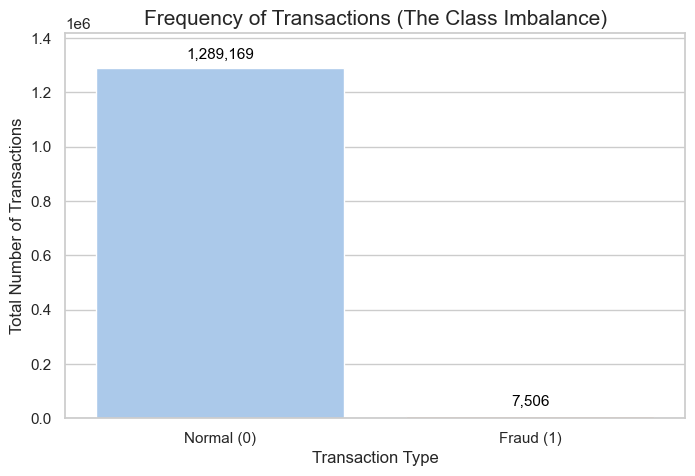

In [ ]:
plt.figure(figsize=(8, 5))

# count plot to show frequency of each class in the training data
ax = sns.countplot(data=cc_train, x=tgt_col, palette='pastel', hue=tgt_col, legend=False)

# Adding clear labels to X-axis instead of just '0' and '1' for understanding.
ax.set_xticklabels(['Normal (0)', 'Fraud (1)']) #ignore the warning for ticks iteration

plt.title('Frequency of Transactions (The Class Imbalance)', fontsize=15)
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Total Number of Transactions', fontsize=12)

# Adding exact numbers on top of bars so tiny fraud bar is readable
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.ylim(0, cc_train[tgt_col].value_counts().max() * 1.1) # Add some headroom
plt.show()

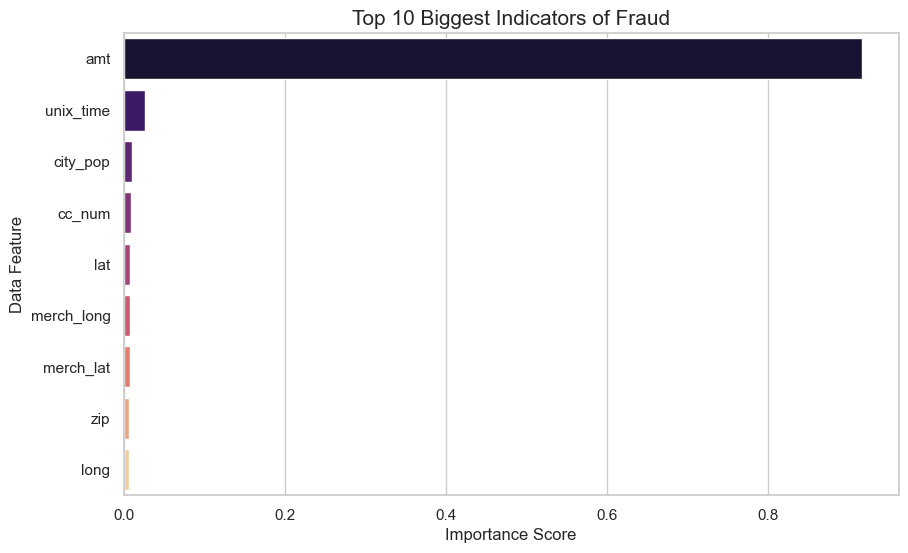

In [8]:
plt.figure(figsize=(10, 6))

# Extracted importance scores from my trained engine
importance_scores = fraud_engine.feature_importances_

# Created clean table sorting the features by how important they are
feat_df = pd.DataFrame({
    'Feature': num_cols,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False).head(10) # Grab the top 10

# Created a horizontal bar chart
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)

plt.title("Top 10 Biggest Indicators of Fraud", fontsize=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Data Feature", fontsize=12)
plt.show()